In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import sklearn.metrics as skm

import tensorflow as tf

from tensorflow.keras.layers import Input, Lambda, Dense, Reshape, Flatten, \
    LSTM, Concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

from math import *

from sklearn.metrics import mean_squared_error

tf.compat.v1.enable_eager_execution()

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
obs_data = np.load('/content/gdrive/My Drive/Colab Notebooks/VisobsFull.npy', allow_pickle=True)
combined_data = obs_data

In [4]:
data_list = []

for element in combined_data: 
  if element <= 9000:
    data_list.append(element)

print(len(data_list))

15512


In [5]:
combined_data = np.array(data_list)
print(combined_data)
print(len(combined_data))
arr_length = len(combined_data)

[1200.         1233.33333333  633.33333333 ... 7000.         7999.66666667
 5399.66666667]
15512


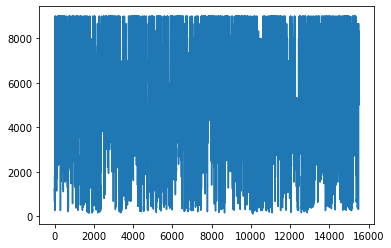

In [6]:
plt.plot(combined_data)

In [7]:
temp_data = combined_data

combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
print(combined_data)
print(len(combined_data))

[1200.         1233.33333333  633.33333333 ... 7000.         7999.66666667
 5399.66666667]
77560


In [8]:
combined_data = np.reshape(combined_data, (arr_length,5), order = 'F')
print(combined_data)
print(combined_data.shape)

[[1200.         1200.         1200.         1200.         1200.        ]
 [1233.33333333 1233.33333333 1233.33333333 1233.33333333 1233.33333333]
 [ 633.33333333  633.33333333  633.33333333  633.33333333  633.33333333]
 ...
 [7000.         7000.         7000.         7000.         7000.        ]
 [7999.66666667 7999.66666667 7999.66666667 7999.66666667 7999.66666667]
 [5399.66666667 5399.66666667 5399.66666667 5399.66666667 5399.66666667]]
(15512, 5)


13960


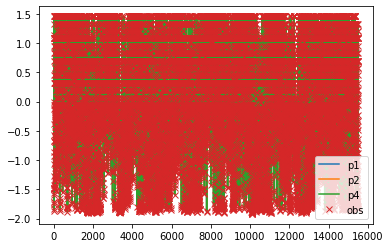

In [9]:
# Split into training data
TRAIN_SPLIT = np.int(0.9*len(combined_data))
print(TRAIN_SPLIT)

# Normalize the training data
data_mean = np.mean(combined_data[:TRAIN_SPLIT], axis=0)
data_std = np.std(combined_data[:TRAIN_SPLIT], axis=0)

dataset = (combined_data-data_mean)/data_std

# Plot part of data to make sure concatenation and normalization was successful
plt.plot(dataset[:,0])
plt.plot(dataset[:,1])
plt.plot(dataset[:,3])
plt.plot(dataset[:,4],'x')
plt.legend(['p1','p2','p4','obs'])

In [10]:
def customLoss(true,pred):
    diff = true - pred

    greater = K.greater(diff,0)
    greater = K.cast(greater, K.floatx()) #0 for lower, 1 for greater
    greater = greater + 2                 #1 for lower, 2 for greater

    #use some kind of loss here, such as mse or mae, or pick one from keras
    #using mse:
    return K.mean(greater*K.abs(diff))

In [11]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

past_history = 48
future_target = 3
STEP = 1

x_train_multi, y_train_multi = multivariate_data(dataset, dataset[:, 4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_multi, y_val_multi = multivariate_data(dataset, dataset[:, 4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [12]:
# Data shape
print ('Single window of past history : {}'.format(x_train_multi[0].shape))
print ('\n Target temperature to predict : {}'.format(y_train_multi[0].shape))

BATCH_SIZE = 16
BUFFER_SIZE = 1000000

train_data_multi = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
train_data_multi = train_data_multi.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_multi = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
val_data_multi = val_data_multi.batch(BATCH_SIZE).repeat()

Single window of past history : (48, 5)

 Target temperature to predict : (3,)


In [13]:
def create_time_steps(length):
  return list(range(-length, 0))

In [14]:
mean_error_ave = 0

true_list = []
pred_list = []

In [15]:
def multi_step_plot(history, true_future, prediction):
  global mean_error_ave
  x = np.array(true_future).tolist()
  y = np.array(prediction).tolist()

  print(history)
  
  mean = 0
  for i in range(1) :
    mean = mean + ((x[i] - y[i])**2)
  mean_error = sqrt(mean/6)
  print("mean error is ", mean_error)
  mean_error_ave = mean_error_ave + (mean_error/6)

  
  for element in x :
    true_list.append(element)

  for element in y :
    pred_list.append(element)
  
  plt.figure(figsize=(12, 6))
  num_in = create_time_steps(len(history))
  num_out = len(true_future)

  plt.plot(num_in, np.array(history[:, 1]), label='History')
  plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'b',
           label='True Future')
  if prediction.any():
    plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'r',
             label='Predicted Future')
  plt.legend(loc='upper left')
  plt.show()

In [16]:
#for x, y in train_data_multi.take(1):
  #multi_step_plot(x[0], y[0], np.array([0]))

multi_step_model = tf.keras.models.Sequential()
multi_step_model.add(tf.keras.layers.LSTM(128,
                                          return_sequences=True,
                                          input_shape=x_train_multi.shape[-2:]))
multi_step_model.add(tf.keras.layers.LSTM(16, activation='softsign',dropout = 0.5))
multi_step_model.add(tf.keras.layers.Dense(future_target))

multi_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(clipvalue=1.0), loss=customLoss)

EVALUATION_INTERVAL = 200
EPOCHS = 10

multi_step_history = multi_step_model.fit(train_data_multi, epochs=EPOCHS,
                                          steps_per_epoch=EVALUATION_INTERVAL,
                                          validation_data=val_data_multi,
                                          validation_steps=50)

Epoch 1/10
200/200 [==============================] - 13s 64ms/step - loss: 1.5369 - val_loss: 1.2798
Epoch 2/10
200/200 [==============================] - 12s 62ms/step - loss: 1.2457 - val_loss: 1.2155
Epoch 3/10
200/200 [==============================] - 12s 61ms/step - loss: 1.2129 - val_loss: 1.1777
Epoch 4/10
200/200 [==============================] - 12s 61ms/step - loss: 1.1616 - val_loss: 1.1523
Epoch 5/10
200/200 [==============================] - 12s 61ms/step - loss: 1.1740 - val_loss: 1.1704
Epoch 6/10
200/200 [==============================] - 13s 63ms/step - loss: 1.1375 - val_loss: 1.1461
Epoch 7/10
200/200 [==============================] - 12s 60ms/step - loss: 1.1593 - val_loss: 1.1342
Epoch 8/10
200/200 [==============================] - 12s 61ms/step - loss: 1.1428 - val_loss: 1.1423
Epoch 9/10
200/200 [==============================] - 12s 61ms/step - loss: 1.1626 - val_loss: 1.1311
Epoch 10/10
200/200 [==============================] - 12s 60ms/step - loss: 1.121

In [17]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

In [18]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

for x, y in val_data_multi.take(100):
  multi_step_plot(data_mean[4]+data_std[4]*x[0], data_mean[4]+data_std[4]*y[0], 
                  data_mean[4]+data_std[4]*multi_step_model.predict(x)[0])

print("mean error average is ", mean_error_ave)

Output hidden; open in https://colab.research.google.com to view.

In [19]:
bins = [0, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
true_bins = pd.cut(true_list, bins, labels=[0,1,2,3,4,5,6,7])
pred_bins = pd.cut(pred_list, bins, labels=[0,1,2,3,4,5,6,7])
print(true_bins)
print(pred_bins)

[3, 4, 6, 6, 6, ..., 5, 6, 7, 7, 7]
Length: 300
Categories (8, int64): [0 < 1 < 2 < 3 < 4 < 5 < 6 < 7]
[3, 4, 4, 6, 6, ..., 6, 6, 7, 7, 7]
Length: 300
Categories (8, int64): [0 < 1 < 2 < 3 < 4 < 5 < 6 < 7]


In [20]:
labels = ['1','2','3','4','5','6','7'] 
cm = skm.confusion_matrix(true_bins, pred_bins)
print(cm)
print(skm.classification_report(true_bins,pred_bins),labels)

[[  0   1   1   2   0   0   1]
 [  0   2   1   3   1   1   0]
 [  0   0   3   1   2   0   1]
 [  0   0   0   6   5   0   0]
 [  0   0   2   2   6  10   5]
 [  0   0   1   2   3  25  42]
 [  0   0   0   4   1  23 143]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         5
           2       0.67      0.25      0.36         8
           3       0.38      0.43      0.40         7
           4       0.30      0.55      0.39        11
           5       0.33      0.24      0.28        25
           6       0.42      0.34      0.38        73
           7       0.74      0.84      0.79       171

    accuracy                           0.62       300
   macro avg       0.41      0.38      0.37       300
weighted avg       0.59      0.62      0.60       300
 ['1', '2', '3', '4', '5', '6', '7']


/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


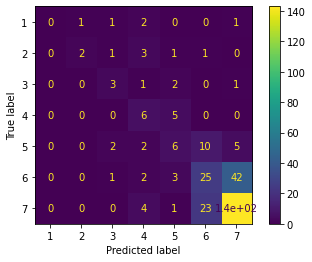

In [21]:
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)

disp = disp.plot()

plt.show()